# Station spectral analysis

This notebook estimates dominant periodic components in station residuals, plots the spectra, and exports tables and aperiodic residuals for the next analysis step.


### Imports


In [1]:
# --- Standard library ---
from pathlib import Path
import sys

# --- Third-party packages ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Doris library ---
PROJECT_ROOT = Path("../..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from doris.analysis.spectral import (
    compute_periodogram,
    estimate_periodogram_threshold,
    find_significant_peaks,
)
from doris.output.tables import Col, save_latex_table


### Paths and parameters


In [2]:
# --- Dataset selection ---
PRODUCT = "stcd"
SOLUTION = "gop25wd04"
STATION = "KIVC"
INPUT_TYPE = "detr"  # "detr" = trend removed, "aper" = trend and periodicity removed
TREND_VARIANT = "weighted_1seg"  # weighted_1seg, weighted_2seg, weighted_multiseg

COMPONENTS = ["dE", "dN", "dU"]

# --- Spectral analysis parameters ---
SPECTRAL_METHOD = "fft"  # "fft" or "lomb_scargle"
METHOD_LABELS = {"fft": "FFT","lomb_scargle": "Lomb-Scargle",}
if SPECTRAL_METHOD not in METHOD_LABELS:
    raise ValueError("SPECTRAL_METHOD must be 'fft' or 'lomb_scargle'.")
METHOD_TAG = SPECTRAL_METHOD
METHOD_LABEL = METHOD_LABELS[SPECTRAL_METHOD]

MIN_PERIOD = 0.08  # years
MAX_PERIOD = 2.0  # years
N_FREQUENCIES = 5000  # used only by Lomb-Scargle
FALSE_ALARM_LEVEL = 0.95
N_FALSE_ALARM = 200
N_PEAKS = 5
RANDOM_STATE = 42

# --- Physically relevant periods ---
USE_TARGET_PERIODS = True
TARGET_PERIODS_DAYS = [118.0, 365.25 / 2, 365.25]
TARGET_TOLERANCE_DAYS = 14.0

# --- Paths ---
DATA_DIR = PROJECT_ROOT / "data" / PRODUCT / SOLUTION
EXPORT_DIR = DATA_DIR / "exports" / STATION.lower()
IMAGES_DIR = PROJECT_ROOT / "LaTeX" / "images" / "results" / "stations" / STATION.lower()
TABLES_DIR = PROJECT_ROOT / "LaTeX" / "tables" / "results" / "stations" / STATION.lower()

for directory in [EXPORT_DIR, IMAGES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BASE_NAME = f"{SOLUTION}_{PRODUCT}_{STATION.lower()}"
INPUT_CSV = EXPORT_DIR / f"{BASE_NAME}_{INPUT_TYPE}_{TREND_VARIANT}.csv"
IMAGE_NAME = f"{BASE_NAME}_{INPUT_TYPE}_{TREND_VARIANT}_spectral_{METHOD_TAG}"

PRINT_TABLE_PREVIEW = True

print("Project: ", PROJECT_ROOT)
print("Data:    ", EXPORT_DIR)
print("Input:   ", INPUT_CSV)
print("Method:  ", METHOD_LABEL)


Project:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis
Data:     C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc
Input:    C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg.csv
Method:   FFT


### Load residuals


In [3]:
# --- Load input residuals ---
if INPUT_TYPE not in {"detr", "aper"}:
    raise ValueError("INPUT_TYPE must be 'detr' or 'aper'.")

if not INPUT_CSV.exists():
    candidates = sorted(EXPORT_DIR.glob(f"{BASE_NAME}_{INPUT_TYPE}_*.csv"))
    hint = "\n".join(f"  - {p.name}" for p in candidates) if candidates else "  (no matching files found)"
    raise FileNotFoundError(f"File not found:\n  {INPUT_CSV}\n\nAvailable candidates:\n{hint}")

df_input = pd.read_csv(INPUT_CSV)
value_prefix = "res" if INPUT_TYPE == "detr" else "aper"
value_cols = [f"{value_prefix}_{comp}" for comp in COMPONENTS]
missing = [col for col in ["year", *value_cols] if col not in df_input.columns]
if missing:
    raise KeyError(f"Missing required column(s): {missing}")

df_input = df_input.sort_values("year").reset_index(drop=True)
df_input["t_year"] = df_input["year"] - df_input["year"].iloc[0]

print(f"Loaded {len(df_input)} rows from {INPUT_CSV.resolve()}")
display(df_input[["year", *value_cols]].head())


Loaded 472 rows from C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg.csv


,year,res_dE,res_dN,res_dU
0,2016.454918,-29.128517,-14.361887,38.189182
1,2016.474044,1.815445,-11.943036,2.503041
2,2016.493169,5.459407,5.575814,3.616900
3,2016.512295,5.403369,-5.905335,-0.769240
4,2016.531421,16.147331,-4.586485,10.844619


### Plot input data


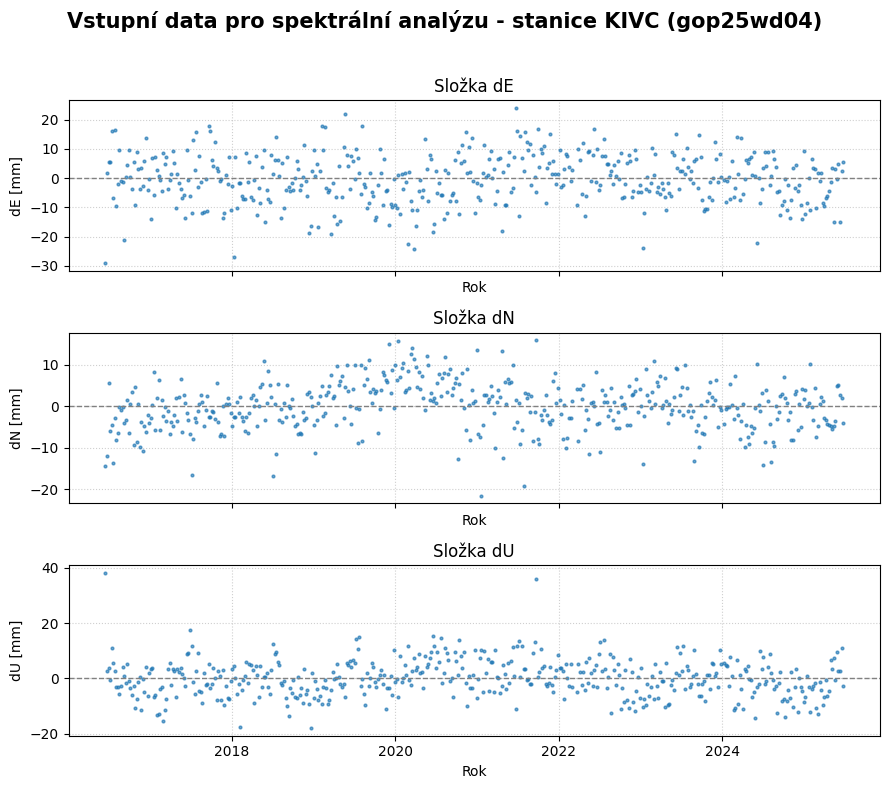

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_spectral_fft_input_residuals.pdf


In [4]:
# --- Plot input residuals ---
component_titles = {comp: f"Složka {comp}" for comp in COMPONENTS}
fig, axes = plt.subplots(len(COMPONENTS), 1, figsize=(9, 8), sharex=True)
if len(COMPONENTS) == 1:
    axes = [axes]

for ax, comp, col in zip(axes, COMPONENTS, value_cols):
    ax.plot(df_input["year"], df_input[col], ".", ms=4, alpha=0.65)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(component_titles[comp], fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xlabel("Rok")

fig.suptitle(
    f"Vstupní data pro spektrální analýzu - stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plot_file = IMAGES_DIR / f"{IMAGE_NAME}_input_residuals.pdf"
fig.savefig(plot_file, bbox_inches="tight", dpi=150)
plt.show()
print("Saved PDF ->", plot_file.resolve())


### Periodogram


In [5]:
# --- Compute periodogram ---
periodogram = compute_periodogram(
    df_input,
    method=SPECTRAL_METHOD,
    time_col="t_year",
    value_cols=value_cols,
    min_period=MIN_PERIOD,
    max_period=MAX_PERIOD,
    n_frequencies=N_FREQUENCIES,
)

if "component" in periodogram.columns:
    periodogram["axis"] = periodogram["component"].str.replace(f"{value_prefix}_", "", regex=False)
else:
    periodogram["axis"] = COMPONENTS[0]

periodogram["period_days"] = periodogram["period"] * 365.25
periodogram = periodogram.sort_values(["axis", "period"]).reset_index(drop=True)

print(f"Computed {len(periodogram)} spectral samples.")
display(periodogram[["axis", "frequency", "period", "period_days", "amplitude", "power"]].head())


Computed 324 spectral samples.


,axis,frequency,period,period_days,amplitude,power
0,dE,12.452079,0.080308,29.332451,0.529004,0.279846
1,dE,12.340900,0.081031,29.596708,0.849546,0.721728
2,dE,12.229720,0.081768,29.865769,0.794754,0.631634
3,dE,12.118541,0.082518,30.139767,0.745791,0.556205
4,dE,12.007362,0.083282,30.418838,0.778921,0.606717


### Significant periods


In [6]:
# --- Estimate false-alarm threshold and select significant peaks ---
threshold = estimate_periodogram_threshold(
    df_input,
    method=SPECTRAL_METHOD,
    time_col="t_year",
    value_cols=value_cols,
    value_col="amplitude",
    false_alarm_level=FALSE_ALARM_LEVEL,
    n_permutations=N_FALSE_ALARM,
    min_period=MIN_PERIOD,
    max_period=MAX_PERIOD,
    n_frequencies=N_FREQUENCIES,
    random_state=RANDOM_STATE,
)


def prepare_peak_table(peaks):
    peaks = peaks.copy()
    if peaks.empty:
        peaks["axis"] = []
        peaks["period_days"] = []
        peaks["target_period_days"] = []
        return peaks

    peaks["axis"] = peaks["component"].str.replace(f"{value_prefix}_", "", regex=False)
    peaks["period_days"] = peaks["period"] * 365.25
    if "target_period_days" not in peaks.columns:
        peaks["target_period_days"] = np.nan
    return peaks


def select_target_period_peaks(peaks, target_periods_days, tolerance_days):
    rows = []

    for comp in COMPONENTS:
        comp_peaks = peaks[peaks["axis"] == comp]
        for target_days in target_periods_days:
            in_window = comp_peaks[
                (comp_peaks["period_days"] >= target_days - tolerance_days)
                & (comp_peaks["period_days"] <= target_days + tolerance_days)
            ]
            if in_window.empty:
                continue

            best = in_window.sort_values("amplitude", ascending=False).iloc[0].copy()
            best["target_period_days"] = target_days
            rows.append(best)

    if not rows:
        return peaks.iloc[0:0].copy()

    selected = pd.DataFrame(rows)
    selected["target_diff_days"] = (selected["period_days"] - selected["target_period_days"]).abs()
    selected = selected.sort_values(["axis", "target_period_days", "target_diff_days", "amplitude"])
    selected = selected.drop_duplicates(subset=["axis", "period_days", "frequency"], keep="first")
    return selected.sort_values(["axis", "target_period_days"]).reset_index(drop=True)


all_significant_peaks = find_significant_peaks(
    periodogram,
    threshold=threshold,
    value_col="amplitude",
    n_peaks=1000,
)
all_significant_peaks = prepare_peak_table(all_significant_peaks)

if USE_TARGET_PERIODS:
    significant_peaks = select_target_period_peaks(
        all_significant_peaks,
        TARGET_PERIODS_DAYS,
        TARGET_TOLERANCE_DAYS,
    )
else:
    significant_peaks = (
        all_significant_peaks
        .sort_values(["axis", "amplitude"], ascending=[True, False])
        .groupby("axis", as_index=False, group_keys=False)
        .head(N_PEAKS)
        .reset_index(drop=True)
    )

print(f"False-alarm threshold ({FALSE_ALARM_LEVEL:.0%}): {threshold:.3f} mm")
if USE_TARGET_PERIODS:
    print(
        "Target periods:",
        ", ".join(f"{period:.1f} d" for period in TARGET_PERIODS_DAYS),
        f"(+/- {TARGET_TOLERANCE_DAYS:.1f} d)",
    )

display_cols = ["axis", "target_period_days", "period_days", "period", "frequency", "amplitude", "power"]
display(significant_peaks[display_cols].round(3))


False-alarm threshold (95%): 2.184 mm
Target periods: 118.0 d, 182.6 d, 365.2 d (+/- 14.0 d)


,axis,target_period_days,period_days,period,frequency,amplitude,power
0,dU,365.25,365.026,0.999,1.001,2.983,8.897


### Significant periods table


In [7]:
# --- Significant periods LaTeX table ---
peaks_table = significant_peaks.copy()
if peaks_table.empty:
    peaks_table = pd.DataFrame(columns=["axis", "target_period_days", "period_days", "period", "frequency", "amplitude", "power"])

tex_file = TABLES_DIR / f"{IMAGE_NAME}_significant_periods.tex"

latex_peaks = save_latex_table(
    peaks_table,
    tex_file,
    cols=[
        Col("axis", "Složka", None),
        Col("target_period_days", "Cílová perioda [dny]", 1),
        Col("period_days", "Perioda [dny]", 1),
        Col("period", "Perioda [rok]", 3),
        Col("frequency", "Frekvence [cyklů/rok]", 3),
        Col("amplitude", "Amplituda [mm]", 3),
    ],
    index=False,
    caption=(
        f"Významné periody reziduí stanice {STATION.upper()} pro řešení {SOLUTION} "
        f"určené metodou {METHOD_LABEL}."
    ),
    label=f"tab:{IMAGE_NAME}_significant_periods",
    escape=False,
    print_preview=PRINT_TABLE_PREVIEW,
)

print("Saved TeX ->", tex_file.resolve())


\begin{table}[htbp]
\caption{Významné periody reziduí stanice KIVC pro řešení gop25wd04 určené metodou FFT.}
\label{tab:gop25wd04_stcd_kivc_detr_weighted_1seg_spectral_fft_significant_periods}
\begin{tabular}{lrrrrr}
\toprule
Složka & Cílová perioda [dny] & Perioda [dny] & Perioda [rok] & Frekvence [cyklů/rok] & Amplituda [mm] \\
\midrule
dU & 365.2 & 365.0 & 0.999 & 1.001 & 2.983 \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_spectral_fft_significant_periods.tex


### Periodogram plot


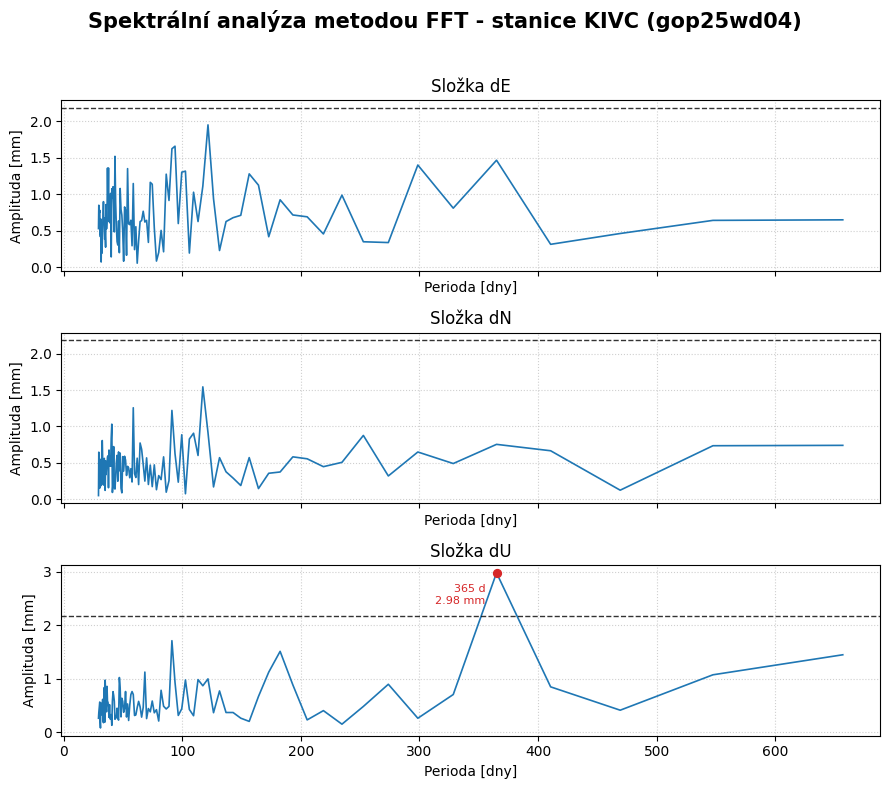

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_spectral_fft_periodogram.pdf


In [8]:
# --- Plot periodogram with significant peaks ---
fig, axes = plt.subplots(len(COMPONENTS), 1, figsize=(9, 8), sharex=True)
if len(COMPONENTS) == 1:
    axes = [axes]

for ax, comp in zip(axes, COMPONENTS):
    df_comp = periodogram[periodogram["axis"] == comp]
    peaks_comp = significant_peaks[significant_peaks["axis"] == comp] if not significant_peaks.empty else significant_peaks

    ax.plot(df_comp["period_days"], df_comp["amplitude"], color="tab:blue", linewidth=1.2)
    ax.axhline(threshold, color="black", linestyle="--", linewidth=1.0, alpha=0.8)

    if not peaks_comp.empty:
        ax.scatter(peaks_comp["period_days"], peaks_comp["amplitude"], color="tab:red", s=32, zorder=3)
        for _, peak in peaks_comp.iterrows():
            ax.annotate(
                f"{peak['period_days']:.0f} d\n{peak['amplitude']:.2f} mm",
                (peak["period_days"], peak["amplitude"]),
                xytext=(-8, -8),
                textcoords="offset points",
                ha="right",
                va="top",
                fontsize=8,
                color="tab:red",
            )

    ax.set_title(component_titles[comp], fontweight="normal")
    ax.set_ylabel("Amplituda [mm]")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xlabel("Perioda [dny]")

fig.suptitle(
    f"Spektrální analýza metodou {METHOD_LABEL} - stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plot_file = IMAGES_DIR / f"{IMAGE_NAME}_periodogram.pdf"
fig.savefig(plot_file, bbox_inches="tight", dpi=150)
plt.show()
print("Saved PDF ->", plot_file.resolve())


### Periodic reconstruction


In [9]:
# --- Reconstruct selected periodic signal ---
def fit_periodic_signal(time, values, periods):
    mask = np.isfinite(time) & np.isfinite(values)
    fitted = np.full_like(values, np.nan, dtype=float)

    if mask.sum() < 3 or len(periods) == 0:
        fitted[mask] = 0.0
        return fitted

    t = time[mask]
    y = values[mask]
    t0 = t[0]

    columns = [np.ones_like(t)]
    for period in periods:
        omega = 2 * np.pi / period
        columns.append(np.sin(omega * (t - t0)))
        columns.append(np.cos(omega * (t - t0)))

    design = np.column_stack(columns)
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    fitted[mask] = design @ coef
    return fitted

# Build periodic and aperiodic columns.
df_aper = df_input.copy()
variance_rows = []

time = df_input["t_year"].to_numpy(dtype=float)

for comp, col in zip(COMPONENTS, value_cols):
    comp_peaks = significant_peaks[significant_peaks["axis"] == comp] if not significant_peaks.empty else significant_peaks
    selected_periods = comp_peaks["period"].to_numpy(dtype=float) if not comp_peaks.empty else np.array([], dtype=float)

    values = df_input[col].to_numpy(dtype=float)
    periodic = fit_periodic_signal(time, values, selected_periods)
    aperiodic = values - periodic

    df_aper[f"per_{comp}"] = periodic
    df_aper[f"aper_{comp}"] = aperiodic

    finite = np.isfinite(values) & np.isfinite(aperiodic)
    var_before = np.var(values[finite], ddof=1) if finite.sum() > 1 else np.nan
    var_after = np.var(aperiodic[finite], ddof=1) if finite.sum() > 1 else np.nan
    reduction = var_before - var_after
    reduction_pct = 100 * reduction / var_before if np.isfinite(var_before) and var_before != 0 else np.nan

    variance_rows.append({
        "axis": comp,
        "n_periods": len(selected_periods),
        "var_before": var_before,
        "var_after": var_after,
        "var_reduction": reduction,
        "var_reduction_pct": reduction_pct,
    })

variance_df = pd.DataFrame(variance_rows)
display(variance_df.round(3))


,axis,n_periods,var_before,var_after,var_reduction,var_reduction_pct
0,dE,0,71.396,71.396,0.000,0.000
1,dN,0,33.442,33.442,0.000,0.000
2,dU,1,45.664,41.221,4.443,9.729


### Periodic reconstruction plot


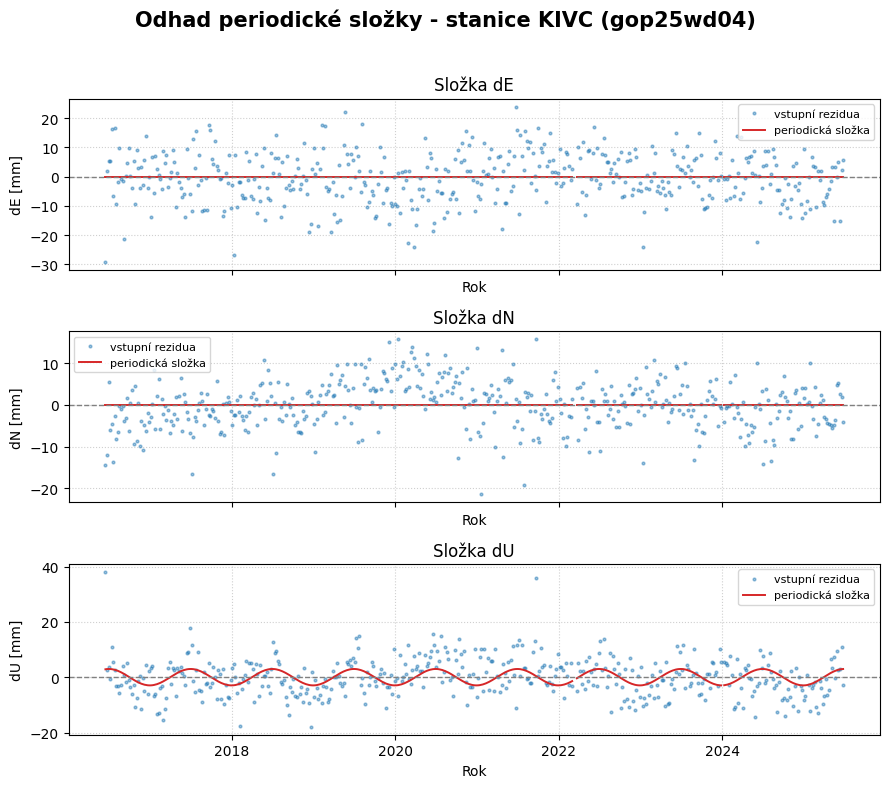

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_spectral_fft_periodic_component.pdf


In [10]:
# --- Plot input residuals and periodic reconstruction ---
fig, axes = plt.subplots(len(COMPONENTS), 1, figsize=(9, 8), sharex=True)
if len(COMPONENTS) == 1:
    axes = [axes]

for ax, comp, col in zip(axes, COMPONENTS, value_cols):
    ax.plot(df_aper["year"], df_aper[col], ".", ms=4, alpha=0.45, label="vstupní rezidua")
    ax.plot(df_aper["year"], df_aper[f"per_{comp}"], color="tab:red", linewidth=1.4, label="periodická složka")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(component_titles[comp], fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xlabel("Rok")
    ax.legend(fontsize=8)

fig.suptitle(
    f"Odhad periodické složky - stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plot_file = IMAGES_DIR / f"{IMAGE_NAME}_periodic_component.pdf"
fig.savefig(plot_file, bbox_inches="tight", dpi=150)
plt.show()
print("Saved PDF ->", plot_file.resolve())


### Aperiodic residuals plot


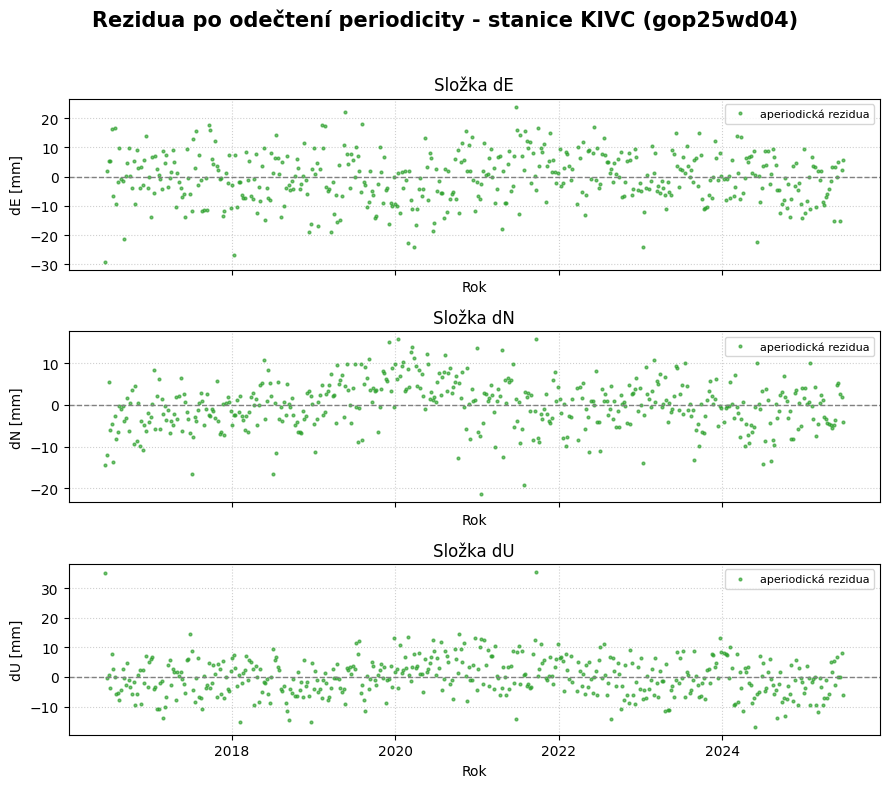

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_spectral_fft_aperiodic_residuals.pdf


In [11]:
# --- Plot residuals after periodicity removal ---
fig, axes = plt.subplots(len(COMPONENTS), 1, figsize=(9, 8), sharex=True)
if len(COMPONENTS) == 1:
    axes = [axes]

for ax, comp in zip(axes, COMPONENTS):
    ax.plot(df_aper["year"], df_aper[f"aper_{comp}"], ".", ms=4, alpha=0.65, color="tab:green", label="aperiodická rezidua")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(component_titles[comp], fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xlabel("Rok")
    ax.legend(fontsize=8)

fig.suptitle(
    f"Rezidua po odečtení periodicity - stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plot_file = IMAGES_DIR / f"{IMAGE_NAME}_aperiodic_residuals.pdf"
fig.savefig(plot_file, bbox_inches="tight", dpi=150)
plt.show()
print("Saved PDF ->", plot_file.resolve())


### Variance reduction table


In [12]:
# --- Variance reduction LaTeX table ---
tex_file = TABLES_DIR / f"{IMAGE_NAME}_variance_reduction.tex"

latex_variance = save_latex_table(
    variance_df,
    tex_file,
    cols=[
        Col("axis", "Složka", None),
        Col("n_periods", "Počet period", None),
        Col("var_before", "Rozptyl před [mm$^2$]", 3),
        Col("var_after", "Rozptyl po [mm$^2$]", 3),
        Col("var_reduction", "Snížení [mm$^2$]", 3),
        Col("var_reduction_pct", "Snížení [\\%]", 1),
    ],
    index=False,
    caption=(
        f"Snížení rozptylu po odstranění významných periodických složek "
        f"určených metodou {METHOD_LABEL} pro stanici {STATION.upper()} a řešení {SOLUTION}."
    ),
    label=f"tab:{IMAGE_NAME}_variance_reduction",
    escape=False,
    print_preview=PRINT_TABLE_PREVIEW,
)

print("Saved TeX ->", tex_file.resolve())


\begin{table}[htbp]
\caption{Snížení rozptylu po odstranění významných periodických složek určených metodou FFT pro stanici KIVC a řešení gop25wd04.}
\label{tab:gop25wd04_stcd_kivc_detr_weighted_1seg_spectral_fft_variance_reduction}
\begin{tabular}{llrrrr}
\toprule
Složka & Počet period & Rozptyl před [mm$^2$] & Rozptyl po [mm$^2$] & Snížení [mm$^2$] & Snížení [\%] \\
\midrule
dE & 0 & 71.396 & 71.396 & 0.000 & 0.0 \\
dN & 0 & 33.442 & 33.442 & 0.000 & 0.0 \\
dU & 1 & 45.664 & 41.221 & 4.443 & 9.7 \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_spectral_fft_variance_reduction.tex


### Export aperiodic residuals


In [13]:
# --- Export aperiodic residuals ---
APER_CSV = EXPORT_DIR / f"{BASE_NAME}_aper_{TREND_VARIANT}.csv"

export_cols = [col for col in df_aper.columns if col not in {"t_year"}]
df_aper[export_cols].to_csv(APER_CSV, index=False, float_format="%.6f")

print("Saved CSV ->", APER_CSV.resolve())
display(df_aper[["year", *[f"aper_{comp}" for comp in COMPONENTS]]].head())


Saved CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_aper_weighted_1seg.csv


,year,aper_dE,aper_dN,aper_dU
0,2016.454918,-29.128517,-14.361887,35.312961
1,2016.474044,1.815445,-11.943036,-0.448905
2,2016.493169,5.459407,5.575814,0.631590
3,2016.512295,5.403369,-5.905335,-3.745075
4,2016.531421,16.147331,-4.586485,7.920966
